In [1]:
import pandas as pd

# Pfad zur Datei
file_path = r"C:\Users\SanL\Uni\Denmark_Semester3\Project_ABA_Spring2026\IUCN_data\assessments.csv"

# CSV einlesen
df1 = pd.read_csv(file_path)

# Erste Zeilen anzeigen
print(df1.head())

# Spalten anzeigen
print(df1.columns)

   assessmentId  internalTaxonId           scientificName  \
0        495907            10041      Heosemys annandalii   
1        497499        132523146         Hubbsina turneri   
2        497550            10267  Hungerfordia pelewensis   
3        499158            10825    Indotestudo forstenii   
4        499618            10950    Pangshura sylhetensis   

         redlistCategory                     redlistCriteria  yearPublished  \
0  Critically Endangered                            A2cd+4cd           2021   
1  Critically Endangered  B1ab(i,ii,iii,iv)+2ab(i,ii,iii,iv)           2019   
2             Endangered            B1ab(ii,iii)+2ab(ii,iii)           2012   
3  Critically Endangered                                A4cd           2021   
4  Critically Endangered                            A2cd+4cd           2021   

            assessmentDate  criteriaVersion language  \
0  2018-03-13 00:00:00 UTC              3.1  English   
1  2018-04-17 00:00:00 UTC              3.1  E

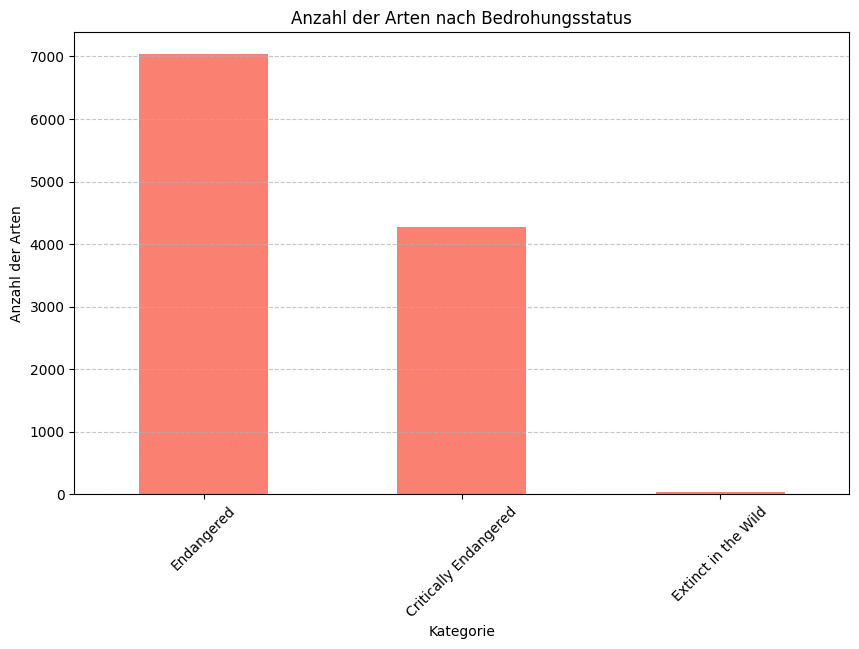

In [2]:
import matplotlib.pyplot as plt

# Die Zählung speichern
status_counts = df1['redlistCategory'].value_counts()

# Plot erstellen
plt.figure(figsize=(10,6))
status_counts.plot(kind='bar', color='salmon')
plt.title('Anzahl der Arten nach Bedrohungsstatus')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl der Arten')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [3]:
# Nur die extrem gefährdeten Arten in eine neue Liste packen
critically_endangered = df1[df1['redlistCategory'] == 'Critically Endangered']

# Die Liste der Namen für GBIF exportieren
species_list = critically_endangered['scientificName'].unique().tolist()
print(f"Du hast {len(species_list)} kritisch gefährdete Arten ausgewählt.")

Du hast 4277 kritisch gefährdete Arten ausgewählt.


In [4]:
print(species_list[:5])

['Heosemys annandalii', 'Hubbsina turneri', 'Indotestudo forstenii', 'Pangshura sylhetensis', 'Kubaryia pilikia']


In [5]:
import pandas as pd
from pygbif import occurrences as occ
import urllib3
import time
import os

# SSL-Warnungen unterdrücken (für den Fall, dass Zertifikate Probleme machen)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Wir nehmen nur die ersten 500 Arten
subset_species = species_list[:500] 
output_file = "clustered_species_first_500.csv"

# Datei löschen, falls sie schon existiert (sauberer Neustart)
if os.path.exists(output_file):
    os.remove(output_file)

print(f"🚀 Starte Prozess für die ersten {len(subset_species)} Arten...")

for i, species in enumerate(subset_species):
    success = False
    retries = 0
    
    # Retry-Logik für 429 Errors
    while not success and retries < 3:
        try:
            # GBIF Abfrage
            search_res = occ.search(scientificName=species, hasCoordinate=True, limit=300, verify=False)
            
            if search_res['results']:
                # Daten in DataFrame laden
                temp_df = pd.DataFrame([{
                    'species': species,
                    'lat': r.get('decimalLatitude'),
                    'lon': r.get('decimalLongitude'),
                    'country': r.get('country'),
                    'year': r.get('year')
                } for r in search_res['results']])

                # --- CLUSTERING (11km Raster) ---
                temp_df['lat_grid'] = temp_df['lat'].round(1)
                temp_df['lon_grid'] = temp_df['lon'].round(1)
                clustered_df = temp_df.drop_duplicates(subset=['lat_grid', 'lon_grid'])
                
                final_df = clustered_df[['species', 'lat', 'lon', 'country', 'year']]

                # Speichern (Append-Modus)
                final_df.to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)
                
                print(f"[{i+1}/{len(subset_species)}] ✅ {species}: {len(final_df)} Cluster gespeichert.")
            else:
                print(f"[{i+1}/{len(subset_species)}] ⚠️ {species}: Keine Daten gefunden.")
            
            success = True
            # Etwas längere Pause zur Sicherheit gegen Sperren
            time.sleep(0.6) 

        except Exception as e:
            if "429" in str(e):
                print(f"🛑 Rate Limit (429). Schlafe 30 Sekunden...")
                time.sleep(2)
                retries += 1
            else:
                print(f"❌ Fehler bei {species}: {e}")
                break # Bei anderen Fehlern zur nächsten Art springen

print(f"\n--- ✅ Fertig! Die ersten {len(subset_species)} Arten sind in '{output_file}' ---")

🚀 Starte Prozess für die ersten 500 Arten...
[1/500] ✅ Heosemys annandalii: 73 Cluster gespeichert.
[2/500] ✅ Hubbsina turneri: 22 Cluster gespeichert.
[3/500] ✅ Indotestudo forstenii: 4 Cluster gespeichert.
[4/500] ✅ Pangshura sylhetensis: 40 Cluster gespeichert.
[5/500] ⚠️ Kubaryia pilikia: Keine Daten gefunden.
[6/500] ✅ Ameca splendens: 16 Cluster gespeichert.
[7/500] ✅ Obovaria haddletoni: 3 Cluster gespeichert.
[8/500] ✅ Lemiox rimosus: 83 Cluster gespeichert.
[9/500] ✅ Malacochersus tornieri: 53 Cluster gespeichert.
[10/500] ✅ Margaritifera hembeli: 27 Cluster gespeichert.
[11/500] ✅ Medionidus walkeri: 20 Cluster gespeichert.
[12/500] ✅ Megalagrion jugorum: 1 Cluster gespeichert.
[13/500] ✅ Megalagrion oceanicum: 15 Cluster gespeichert.
[14/500] ✅ Mictocaris halope: 1 Cluster gespeichert.
[15/500] ✅ Telmatobius sanborni: 2 Cluster gespeichert.
[16/500] ✅ Neochanna burrowsius: 28 Cluster gespeichert.
[17/500] ✅ Nilssonia formosa: 12 Cluster gespeichert.
[18/500] ✅ Mauremys sinen

In [6]:
import rasterio

raster_path = "wc2.1_10m_bioc_MPI-ESM1-2-HR_ssp585_2021-2040.tif"

dataset = rasterio.open(raster_path)
print(dataset.count)  # Anzahl der Bands

19


In [7]:
data = dataset.read()
print(data.shape)  # (bands, rows, cols)

(19, 1080, 2160)


In [8]:
def get_temp(lat, lon, dataset):
    try:
        # Koordinate → Rasterindex
        row, col = dataset.index(lon, lat)
        
        # Wert lesen (Band 1 z. B.)
        value = dataset.read(1)[row, col]
        
        return value
    except:
        return None

In [9]:
import pandas as pd

df = pd.read_csv("clustered_species_first_500.csv")

temps = []

for i, row in df.iterrows():
    temp = get_temp(row["lat"], row["lon"], dataset)
    temps.append(temp)

df["future_temp"] = temps

In [10]:
df

,species,lat,lon,country,year,future_temp
0,Heosemys annandalii,14.567334,101.225103,Thailand,2026.0,25.500000
1,Heosemys annandalii,14.182892,100.608396,Thailand,2026.0,28.400000
2,Heosemys annandalii,13.619649,100.529818,Thailand,2026.0,28.799999
3,Heosemys annandalii,13.942645,100.524226,Thailand,2026.0,28.799999
4,Heosemys annandalii,13.636240,100.562888,Thailand,2026.0,28.799999
...,...,...,...,...,...,...
5828,Euastacus girurmulayn,-28.569212,153.262586,Australia,2025.0,19.299999
5829,Euastacus girurmulayn,-28.494589,153.227733,Australia,2024.0,19.600000
5830,Euastacus girurmulayn,-28.405062,153.382267,Australia,2024.0,20.100000
5831,Euastacus girurmulayn,-28.472550,153.380167,Australia,2021.0,20.100000


In [11]:
df["future_temp"].isna().sum()

1845

In [12]:
df_clean = df.dropna(subset=["future_temp"])

In [13]:
df_clean

,species,lat,lon,country,year,future_temp
0,Heosemys annandalii,14.567334,101.225103,Thailand,2026.0,25.500000
1,Heosemys annandalii,14.182892,100.608396,Thailand,2026.0,28.400000
2,Heosemys annandalii,13.619649,100.529818,Thailand,2026.0,28.799999
3,Heosemys annandalii,13.942645,100.524226,Thailand,2026.0,28.799999
4,Heosemys annandalii,13.636240,100.562888,Thailand,2026.0,28.799999
...,...,...,...,...,...,...
5828,Euastacus girurmulayn,-28.569212,153.262586,Australia,2025.0,19.299999
5829,Euastacus girurmulayn,-28.494589,153.227733,Australia,2024.0,19.600000
5830,Euastacus girurmulayn,-28.405062,153.382267,Australia,2024.0,20.100000
5831,Euastacus girurmulayn,-28.472550,153.380167,Australia,2021.0,20.100000


In [14]:
import rasterio
import pandas as pd

# Dein CSV mit Artenbeobachtungen
df = pd.read_csv("clustered_species_first_500.csv")

# Rasterdatei (BIO1)
raster_path = "wc2.1_10m_tmin_ACCESS-CM2_ssp245_2021-2040.tif"
raster = rasterio.open(raster_path)

In [15]:
from rasterio.sample import sample_gen

# Koordinaten als Liste
coords = [(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]

# Rasterwerte extrahieren
future_temps = [val.max() for val in raster.sample(coords)]  # Bio1 ist in °C × 10

# In DataFrame speichern
df['future_temp_2021_2040'] = future_temps

In [16]:
df_clean = df.dropna()
df_clean

,species,lat,lon,country,year,future_temp_2021_2040
0,Heosemys annandalii,14.567334,101.225103,Thailand,2026.0,24.200001
1,Heosemys annandalii,14.182892,100.608396,Thailand,2026.0,26.799999
2,Heosemys annandalii,13.619649,100.529818,Thailand,2026.0,27.799999
3,Heosemys annandalii,13.942645,100.524226,Thailand,2026.0,27.299999
4,Heosemys annandalii,13.636240,100.562888,Thailand,2026.0,27.799999
...,...,...,...,...,...,...
5828,Euastacus girurmulayn,-28.569212,153.262586,Australia,2025.0,19.600000
5829,Euastacus girurmulayn,-28.494589,153.227733,Australia,2024.0,19.799999
5830,Euastacus girurmulayn,-28.405062,153.382267,Australia,2024.0,20.299999
5831,Euastacus girurmulayn,-28.472550,153.380167,Australia,2021.0,20.299999


In [18]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Alle Zeilen mit NaN in den für HeatMap relevanten Spalten entfernen
df_clean = df.dropna(subset=["lat", "lon", "future_temp_2021_2040"])

# Karte erstellen
m = folium.Map(location=[0, 0], zoom_start=2)

# Heatmap
heat_data = [[row['lat'], row['lon'], row['future_temp_2021_2040']] for idx, row in df_clean.iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(m)

# Mouse-over Marker
for idx, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.7,
        popup=f"Species: {row['species']}<br>Temp: {row['future_temp_2021_2040']}°C"
    ).add_to(m)

# Karte speichern
m.save("heatmap_with_tooltip.html")